# Assignment 4.1

Name: Francisco Gutierrez  
Date: September 28, 2026

For this assignment, you will refer to the textbook to solve the practice exercises. **Use Python to answer any coding problems (not R, even if indicated in your textbook).** Use Jupyter Notebook, Google Colab, or a similar software program to complete your assignment. Submit your answers as a **PDF or HTML** file. As a best practice, always label your axes and provide titles for any graphs generated on this assignment. Round all quantitative answers to 2 decimal places.

## Problem # 4.1.

For a point estimate of the mean of a population that is assumed to have a normal distribution,
a data scientist decides to use the average of the sample lower and upper quartiles for the $n = 100$
observations, since unlike the sample mean $\bar{Y}$, the quartiles are not affected by outliers. Evaluate
the precision of this estimator compared to $\bar{Y}$ by randomly generating 100,000 samples of size
100 each from a $N(0, 1)$ distribution and comparing the standard deviation of the 100,000
estimates with the theoretical standard error of $\bar{Y}$.

I compared the average of the two quartiles with the sample mean using 100,000 samples. The quartile average had a standard deviation of **0.11**, while the sample mean had a standard deviation of **0.10**. The theoretical standard error of the sample mean is $1/\sqrt{100} = 0.10$.

The quartile estimator's standard deviation was about **10.00% larger** than the theoretical standard error. That means its estimates varied more from sample to sample, so the sample mean was more precise for this normal population. Quartiles are less sensitive to extreme values, but that benefit comes with some loss of precision here.

Theoretical SE of sample mean: 0.10
Simulated SD of sample mean: 0.10
Simulated SD of quartile average: 0.11
Quartile SD / theoretical SE: 1.10
Percent increase in SD: 10.00%


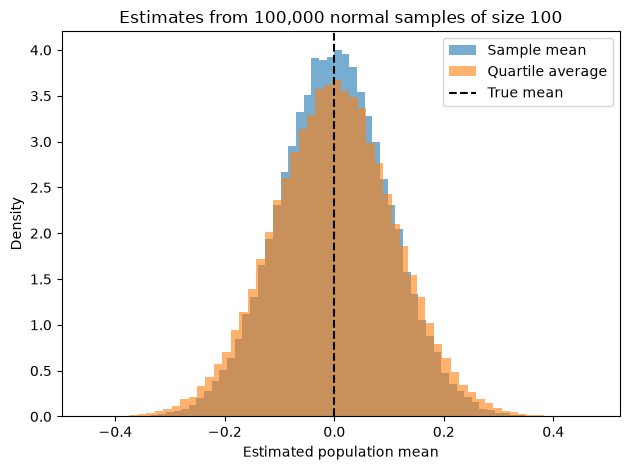

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from pathlib import Path
from IPython.display import display

pd.options.display.float_format = '{:.2f}'.format

def mean_ci(x):
    x = np.asarray(x)
    return stats.t.interval(0.95, len(x) - 1, loc=x.mean(), scale=stats.sem(x))

def welch_summary(a, b):
    a, b = np.asarray(a), np.asarray(b)
    va, vb = a.var(ddof=1) / len(a), b.var(ddof=1) / len(b)
    se = np.sqrt(va + vb)
    df = (va + vb)**2 / (va**2 / (len(a)-1) + vb**2 / (len(b)-1))
    difference = a.mean() - b.mean()
    ci = stats.t.interval(0.95, df, loc=difference, scale=se)
    test = stats.ttest_ind(a, b, equal_var=False)
    return difference, ci, test.statistic, df, test.pvalue

def show_p(p):
    return '< 0.01' if p < 0.005 else f'= {p:.2f}'

np.random.seed(42)
samples = np.random.normal(0, 1, size=(100000, 100))
sample_means = samples.mean(axis=1)
q1, q3 = np.percentile(samples, [25, 75], axis=1)
quartile_estimates = (q1 + q3) / 2
mean_sd = sample_means.std(ddof=1)
quartile_sd = quartile_estimates.std(ddof=1)
theoretical_se = 1 / np.sqrt(100)
print(f'Theoretical SE of sample mean: {theoretical_se:.2f}')
print(f'Simulated SD of sample mean: {mean_sd:.2f}')
print(f'Simulated SD of quartile average: {quartile_sd:.2f}')
print(f'Quartile SD / theoretical SE: {quartile_sd / theoretical_se:.2f}')
print(f'Percent increase in SD: {100*(quartile_sd/theoretical_se-1):.2f}%')
plt.hist(sample_means, bins=60, density=True, alpha=0.6, label='Sample mean')
plt.hist(quartile_estimates, bins=60, density=True, alpha=0.6, label='Quartile average')
plt.axvline(0, color='black', linestyle='--', label='True mean')
plt.xlabel('Estimated population mean')
plt.ylabel('Density')
plt.title('Estimates from 100,000 normal samples of size 100')
plt.legend()
plt.tight_layout()
plt.show()

## Problem # 4.2.

For a sequence of observations of a binary random variable, you observe the geometric random
variable (Section 2.2.2) outcome of the first success on observation number $y = 3$. Find and plot
the likelihood function.

The first success happens on the third observation, so the first two observations must be failures. This gives the likelihood

$$L(p) = (1-p)^2p, \qquad 0 \leq p \leq 1.$$

Taking the derivative gives $L'(p)=(1-p)(1-3p)$. The largest likelihood occurs at $\hat p=1/3$, or **0.33**, where the likelihood is **0.15**. This makes sense because we observed one success in three tries. The graph below shows which values of $p$ fit this outcome best; it is not a probability distribution for $p$.

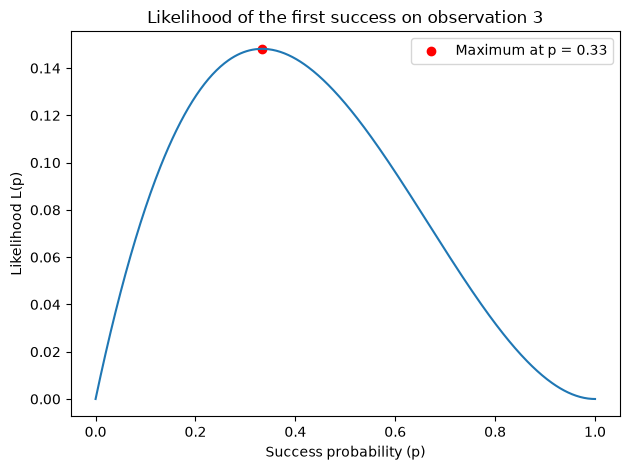

In [2]:
p_grid = np.linspace(0, 1, 501)
likelihood = (1 - p_grid)**2 * p_grid
plt.plot(p_grid, likelihood)
plt.scatter([1/3], [4/27], color='red', label='Maximum at p = 0.33')
plt.xlabel('Success probability (p)')
plt.ylabel('Likelihood L(p)')
plt.title('Likelihood of the first success on observation 3')
plt.legend()
plt.tight_layout()
plt.show()

## Problem # 4.11.

The observations on number of hours of daily TV watching for the 10 subjects in the 2018 GSS
who identified themselves as Islamic were 0, 0, 1, 1, 1, 2, 2, 3, 3, 4.

(a)  Construct and interpret a 95% confidence interval for the population mean.
(b)  Suppose the observation of 4 was incorrectly recorded as 24. What would you obtain for
the 95% confidence interval? What does this suggest about potential effects of outliers on
confidence intervals for means?

**(a)** Since the population standard deviation is unknown, I used a $t$ interval:

$$\bar{x} \pm t_{0.975,9}\frac{s}{\sqrt{n}}.$$

The sample mean is **1.70 hours**, the sample standard deviation is **1.34 hours**, and the 95% confidence interval is **(0.74, 2.66) hours per day**. I am 95% confident that the population mean daily TV time for people identifying as Islamic in the population covered by the GSS is between these values.

This assumes independent, representative observations and a roughly normal population without strong outliers. With only 10 people, the shape assumption matters more. I am treating the observations as a simple random sample for this exercise; the actual GSS survey design could affect the interval.

In [3]:
tv_daily = np.array([0, 0, 1, 1, 1, 2, 2, 3, 3, 4])
ci_daily = mean_ci(tv_daily)
print(f'Mean: {tv_daily.mean():.2f}; sample SD: {tv_daily.std(ddof=1):.2f}')
print(f't critical value (9 df): {stats.t.ppf(0.975, 9):.2f}')
print(f'95% CI: ({ci_daily[0]:.2f}, {ci_daily[1]:.2f}) hours per day')

Mean: 1.70; sample SD: 1.34
t critical value (9 df): 2.26
95% CI: (0.74, 2.66) hours per day


**(b)** Changing 4 to 24 raises the sample mean to **3.70 hours** and the standard deviation to **7.21 hours**. Using the same method gives a 95% confidence interval of **(-1.46, 8.86) hours per day**.

One recording error made the interval much wider and pulled it upward. This shows that an outlier can affect both the estimated mean and its uncertainty. Negative TV time is impossible, so the lower endpoint also shows how unhelpful this interval becomes. The extreme value makes the normality assumption questionable for such a small sample, and I would correct the recording error before using the results.

In [4]:
tv_error = tv_daily.copy()
tv_error[-1] = 24
ci_error = mean_ci(tv_error)
print(f'Mean: {tv_error.mean():.2f}; sample SD: {tv_error.std(ddof=1):.2f}')
print(f'95% CI: ({ci_error[0]:.2f}, {ci_error[1]:.2f}) hours per day')

Mean: 3.70; sample SD: 7.21
95% CI: (-1.46, 8.86) hours per day


## Problem # 4.14.

Using the Students data file, for the corresponding population, construct a 95% confidence interval **(a)** for the mean weekly number of hours spent watching TV; **(b)** to compare females and
males on the mean weekly number of hours spent watching TV. In each case, state assumptions,
including the practical importance of each, and interpret results.

**(a)** The 60 students watched an average of **7.27 hours of TV per week**, with a standard deviation of **6.72 hours**. Using a one-sample $t$ interval, I got a 95% confidence interval of **(5.53, 9.00) hours per week**. If the sample represents the population of similar students, I am 95% confident that their population mean falls in this range.

**(b)** The 31 female students averaged **7.98 hours**, and the 29 male students averaged **6.50 hours** per week. I used Welch's method to estimate the difference, female minus male. The estimated difference is **1.48 hours**, with a 95% confidence interval of **(-2.01, 4.98) hours per week**. Since the interval includes zero, these data do not show a clear difference between the population means. The interval still allows differences of several hours, so it does not show that the two means are equal.

The most important assumptions are independent observations and a sample that represents the population we want to describe. Since these students came from one class, I would be careful about applying the results to all college students. The TV values are right-skewed and include large values. The overall sample size helps the mean interval, but the smaller gender groups make the comparison more sensitive to those values. Welch's method allows unequal variances, so equal population variances are not required.

Data: [Students file](https://stat4ds.rwth-aachen.de/data/Students.dat). Gender is coded 1 = female and 0 = male, as described in the [author's Students questionnaire](https://api.pageplace.de/preview/DT0400.9781292220345_A37747447/preview-9781292220345_A37747447.pdf).

Overall n: 60; mean: 7.27; SD: 6.72
Overall 95% CI: (5.53, 9.00) hours/week


,count,mean,std,median,min,max
group,,,,,,
Female,31,7.98,6.37,7.00,0.00,28.00
Male,29,6.50,7.10,5.00,0.00,37.00


Female minus male mean: 1.48; Welch df: 56.25
95% CI for difference: (-2.01, 4.98) hours/week


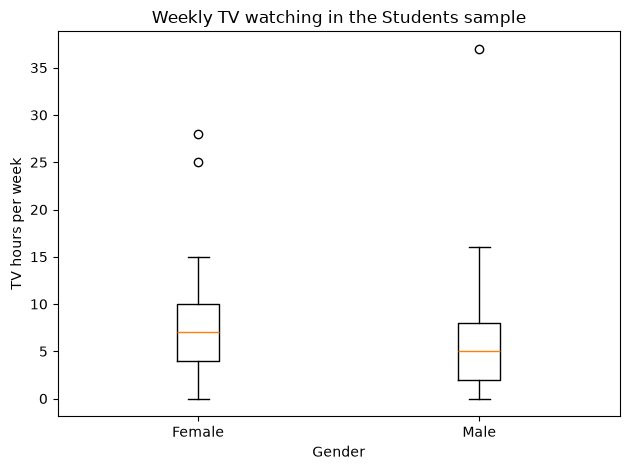

In [5]:
# Local copies from https://stat4ds.rwth-aachen.de/data/
data_dir = Path('data')
if not (data_dir / 'Students.dat').exists():
    data_dir = Path('AAI_500/M4_Assignments/data')
students = pd.read_csv(data_dir / 'Students.dat', sep=r'\s+')
female_tv = students.loc[students.gender == 1, 'tv']
male_tv = students.loc[students.gender == 0, 'tv']
ci_tv = mean_ci(students.tv)
tv_comparison = welch_summary(female_tv, male_tv)
print(f'Overall n: {len(students)}; mean: {students.tv.mean():.2f}; SD: {students.tv.std():.2f}')
print(f'Overall 95% CI: ({ci_tv[0]:.2f}, {ci_tv[1]:.2f}) hours/week')
display(students.assign(group=students.gender.map({1: 'Female', 0: 'Male'})).groupby('group').tv.agg(['count', 'mean', 'std', 'median', 'min', 'max']))
d, ci, t, df, p_value = tv_comparison
print(f'Female minus male mean: {d:.2f}; Welch df: {df:.2f}')
print(f'95% CI for difference: ({ci[0]:.2f}, {ci[1]:.2f}) hours/week')
plt.boxplot([female_tv, male_tv], tick_labels=['Female', 'Male'])
plt.xlabel('Gender')
plt.ylabel('TV hours per week')
plt.title('Weekly TV watching in the Students sample')
plt.tight_layout()
plt.show()

## Problem # 4.31.

The `Houses` data file at the book’s website lists, for 100 home sales in Gainesville, Florida,
several variables, including the selling price in thousands of dollars and whether the house
is new (1 = yes, 0 = no). Prepare a short report in which, stating all assumptions including
the relative importance of each, you conduct descriptive and inferential statistical analyses to
compare the selling prices for new and older homes.

The dataset includes **11 new homes and 89 older homes**. New homes had a mean selling price of **436.45 thousand dollars**, compared with **207.85 thousand dollars** for older homes. Their medians were **427.50** and **190.80 thousand dollars**, respectively. Prices also varied more among new homes: their standard deviation was **219.83 thousand dollars**, compared with **121.04 thousand dollars** for older homes.

I tested $H_0: \mu_{new}-\mu_{older}=0$ against a two-sided alternative using Welch's $t$ test. The test gave **t = 3.39**, **df = 10.76**, and **p = 0.01**, rounded to two decimal places. At the 0.05 level, I would reject the null hypothesis. The estimated mean difference was **228.59 thousand dollars**, and its 95% confidence interval was **(79.60, 377.59) thousand dollars**. These results suggest that new homes sold for more on average, although the wide interval leaves a lot of uncertainty about the size of the difference.

I assumed the sales were independent and reasonably representative of Gainesville home sales during the period covered. Those assumptions are especially important because a biased sample or related sales could make the conclusions misleading. I also assumed the price distributions were suitable for a $t$ comparison. There are some high prices, and only 11 new homes, so the small new-home group makes the normality assumption important. Welch's test does not require equal variances, which is useful because the spreads differ. Finally, this is an observational comparison: differences in size, location, or other features could help explain the price gap. The results do not prove that being new caused the higher prices.

Data: [Houses file](https://stat4ds.rwth-aachen.de/data/Houses.dat).

,count,mean,std,median,min,max
group,,,,,,
New,11,436.45,219.83,427.50,158.85,866.25
Older,89,207.85,121.04,190.80,31.50,880.50


New minus older mean price: 228.59 thousand dollars
95% CI: (79.60, 377.59) thousand dollars
Welch t = 3.39; df = 10.76; two-sided p = 0.01


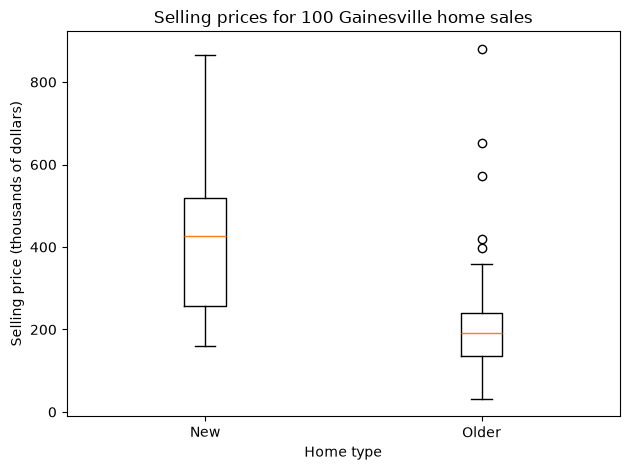

In [6]:
houses = pd.read_csv(data_dir / 'Houses.dat', sep=r'\s+')
new_prices = houses.loc[houses.new == 1, 'price']
old_prices = houses.loc[houses.new == 0, 'price']
display(houses.assign(group=houses.new.map({1: 'New', 0: 'Older'})).groupby('group').price.agg(['count', 'mean', 'std', 'median', 'min', 'max']))
house_comparison = welch_summary(new_prices, old_prices)
d, ci, t, df, p_value = house_comparison
print(f'New minus older mean price: {d:.2f} thousand dollars')
print(f'95% CI: ({ci[0]:.2f}, {ci[1]:.2f}) thousand dollars')
print(f'Welch t = {t:.2f}; df = {df:.2f}; two-sided p {show_p(p_value)}')
plt.boxplot([new_prices, old_prices], tick_labels=['New', 'Older'])
plt.xlabel('Home type')
plt.ylabel('Selling price (thousands of dollars)')
plt.title('Selling prices for 100 Gainesville home sales')
plt.tight_layout()
plt.show()

## Problem 5.6.

Before a Presidential election, polls are taken in two swing states. The Republican candidate
was preferred by 59 of the 100 people sampled in state A and by 525 of 1000 sampled in state
B. Treat these as independent binomial samples, where the parameter $\pi$ is the population
proportion voting Republican in the state.


(a) If we can treat these polls as if the samples were random, use significance tests of $H_0$:
$\pi  = 0.50$ against $H_a:  \pi > 0.50$ to determine which state has greater evidence supporting a
Republican victory. Explain your reasoning.


I used a one-sided proportion $z$ test for each state:

$$z=\frac{\hat{p}-0.50}{\sqrt{0.50(1-0.50)/n}}.$$

State A had **59.00%** support, giving **z = 1.80** and **p = 0.04**. State B had **52.50%** support, giving **z = 1.58** and **p = 0.06**. State A has stronger evidence of a Republican majority because its p-value is smaller. At the 0.05 significance level, I would reject the null for A but not for B. I used the unrounded p-values for these decisions.

This assumes random samples and independent responses, as stated in the question. Under the null, each state has enough expected successes and failures for the normal approximation. B has a larger sample, but A's observed support is farther above 50.00%, even after accounting for sampling variability. These tests give evidence about majority support; they do not guarantee an election result.

In [7]:
poll_rows = []
for state, successes, n in [('A', 59, 100), ('B', 525, 1000)]:
    phat = successes / n
    z = (phat - 0.50) / np.sqrt(0.50 * 0.50 / n)
    p_value = stats.norm.sf(z)
    poll_rows.append({'State': state, 'Sample proportion': phat, 'z': z, 'One-sided p': p_value})
polls = pd.DataFrame(poll_rows).set_index('State')
display(polls)

,Sample proportion,z,One-sided p
State,,,
A,0.59,1.80,0.04
B,0.53,1.58,0.06


(b) Conduct a Bayesian analysis to answer the question in (a) by finding in each case the
posterior $P(\pi < 0.50)$, corresponding to the *P-* value in (a). Use beta(50, 50) priors, which
have standard deviation 0.05 and reflect the pollster’s strong prior belief that $\pi$ almost
surely is between 0.35 and 0.65. Explain any differences between conclusions.

With a beta(50, 50) prior and $x$ successes in $n$ responses, the posterior is

$$\pi\mid x \sim \operatorname{Beta}(50+x,\;50+n-x).$$

For **state A**, the posterior is beta(109, 91), and $P(\pi<0.50\mid x)$ is **0.10**. For **state B**, the posterior is beta(575, 525), and this probability is **0.07**. Under this prior, B has stronger support for a Republican majority because it has the smaller posterior probability of support below 50.00%.

This reverses the ranking from part (a). The prior is centered at 0.50 and adds 100 to the combined beta parameters, so it has a larger effect on A's sample of 100 than on B's sample of 1,000. A's estimate is pulled toward 0.50 more strongly. Also, these posterior probabilities directly describe uncertainty about the population proportion under the model. The p-values in part (a) describe how unusual the sample results would be if the null were true; they are not probabilities that the null is true.

In [8]:
bayes_rows = []
for state, successes, n in [('A', 59, 100), ('B', 525, 1000)]:
    a, b = 50 + successes, 50 + n - successes
    bayes_rows.append({'State': state, 'Posterior alpha': a, 'Posterior beta': b,
                       'Posterior mean': a/(a+b), 'P(pi < 0.50)': stats.beta.cdf(0.50, a, b)})
posterior = pd.DataFrame(bayes_rows).set_index('State')
display(posterior)

,Posterior alpha,Posterior beta,Posterior mean,P(pi < 0.50)
State,,,,
A,109,91,0.55,0.10
B,575,525,0.52,0.07


## Problem 5.8.

For the `Students` data file at the text website, analyze political ideology.

(a) Test whether the population mean $\mu$ differs from 4.0, the moderate response. Report the
*P*-value, and interpret. Make a conclusion using $\alpha$ - level = 0.05.

I tested $H_0:\mu=4.00$ against $H_a:\mu\ne4.00$ with a one-sample $t$ test. The 60 students had a mean ideology score of **3.03** and a standard deviation of **1.64**. The test gave **t = -4.58**, **df = 59**, and **p < 0.01**. I report the small p-value this way instead of rounding it to 0.00.

Since the p-value is below 0.05, I reject the null hypothesis. The data suggest that the population mean differs from the moderate score of 4.00 and is on the more liberal side of the scale. If the true mean were 4.00, a test statistic this far from zero would be unlikely.

This assumes independent, representative observations and treats the ordered ideology scores as approximately equally spaced. The sample size helps with the normal approximation, but the single-class sample limits how broadly I can apply the result.

In [9]:
ideology = students.ideol
ideology_test = stats.ttest_1samp(ideology, popmean=4)
print(f'n = {len(ideology)}; mean = {ideology.mean():.2f}; SD = {ideology.std():.2f}')
print(f't = {ideology_test.statistic:.2f}; df = {len(ideology)-1}')
print(f'Two-sided p {show_p(ideology_test.pvalue)}')

n = 60; mean = 3.03; SD = 1.64
t = -4.58; df = 59
Two-sided p < 0.01


(b) Construct the 95% confidence interval for $\mu$. Explain how results relate to those of the
test in (a).


The 95% confidence interval for the mean ideology score is **(2.61, 3.46)**. I am 95% confident that the population mean for students represented by this sample falls within this range, subject to the assumptions above.

The entire interval is below **4.00**, which agrees with rejecting the two-sided null hypothesis at the 0.05 level. Both methods point to a mean on the more liberal side of moderate.

In [10]:
ci_ideology = mean_ci(ideology)
print(f'95% CI: ({ci_ideology[0]:.2f}, {ci_ideology[1]:.2f})')

95% CI: (2.61, 3.46)


## Problem 5.10.

A study of sheep mentioned in Exercise 1.27 analyzed whether the sheep survived for a year
from the original observation time (1 = yes, 0 = no) as a function of their weight (*kg*) at the
original observation. Stating any assumptions including the conceptual population of interest,
use a *t* test with the data in the Sheep data file at the text website to compare mean weights
of the sheep that survived and did not survive. Interpret the *P*-value.

I compared the mean starting weights using Welch's independent-samples $t$ test. The hypotheses were $H_0:\mu_{survived}=\mu_{did\ not\ survive}$ and a two-sided alternative that the means differ.

The **1,041 sheep that survived** had a mean starting weight of **20.65 kg** and a standard deviation of **4.90 kg**. The **318 sheep that did not survive** averaged **16.00 kg**, with a standard deviation of **5.33 kg**. The estimated difference was **4.65 kg**, with a 95% confidence interval of **(3.99, 5.31) kg**. The test gave **t = 13.87**, **df = 492.02**, and **p < 0.01**.

I would reject the null at the 0.05 level. If the two population means were equal, a difference at least this extreme relative to its standard error would be very unlikely. The sheep that survived tended to be heavier at the start. This does not prove that greater weight caused survival, since age, health, or other factors could affect both.

My conceptual population is sheep living under conditions similar to those in the original study and followed for one year. I assumed each row represents a different sheep, the observations are independent, and the sample reasonably represents that population. Independence and representativeness matter most; shared flock conditions could weaken the independence assumption. Both groups are large, so exact normality is less important, provided there are no extreme values dominating the means. Welch's method does not require equal population variances.

Data: [Sheep file](https://stat4ds.rwth-aachen.de/data/Sheep.dat).

In [11]:
sheep = pd.read_csv(data_dir / 'Sheep.dat', sep=r'\s+')
survived = sheep.loc[sheep.survival == 1, 'weight']
not_survived = sheep.loc[sheep.survival == 0, 'weight']
display(sheep.assign(group=sheep.survival.map({1: 'Survived', 0: 'Did not survive'})).groupby('group').weight.agg(['count', 'mean', 'std', 'min', 'max']))
sheep_comparison = welch_summary(survived, not_survived)
d, ci, t, df, p_value = sheep_comparison
print(f'Survived minus did not survive: {d:.2f} kg')
print(f'95% CI: ({ci[0]:.2f}, {ci[1]:.2f}) kg')
print(f'Welch t = {t:.2f}; df = {df:.2f}; two-sided p {show_p(p_value)}')

,count,mean,std,min,max
group,,,,,
Did not survive,318,16.00,5.33,3.10,32.80
Survived,1041,20.65,4.90,6.10,34.20


Survived minus did not survive: 4.65 kg
95% CI: (3.99, 5.31) kg
Welch t = 13.87; df = 492.02; two-sided p < 0.01


## Problem 5.23. Sentiment Toward AI and Gender

You will use a mock survey dataset that measures public sentiment toward artificial intelligence. Your task is to generate the dataset, construct a contingency table, and test whether sentiment depends on gender

### Dataset creation

Run the starter code below to generate the dataset as a pandas DataFrame named `df_ai`.

In [12]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(2024)

# Sample size
n = 300

# Categories
sentiments = ["Positive", "Neutral", "Negative"]
genders = ["Male", "Female", "Other"]
usage_levels = ["Daily", "Weekly", "Rarely", "Never"]

# Generate the DataFrame
df_ai = pd.DataFrame(
    {
        "sentiment": np.random.choice(sentiments, size=n, p=[0.44, 0.33, 0.23]),
        "gender": np.random.choice(genders, size=n, p=[0.49, 0.48, 0.03]),
        "age": np.random.randint(18, 75, size=n),
        "ai_usage_frequency": np.random.choice(usage_levels, size=n),
        "trust_in_ai": np.random.randint(1, 6, size=n),
    }
)

df_ai.head()

,sentiment,gender,age,ai_usage_frequency,trust_in_ai
0,Neutral,Male,55,Weekly,2
1,Neutral,Male,23,Rarely,3
2,Positive,Male,27,Daily,5
3,Positive,Female,29,Daily,1
4,Positive,Female,58,Rarely,5


| Variable           | Description                         |
|--------------------|-------------------------------------|
| `sentiment`          | Sentiment toward AI                 |
| `gender`             | Gender identity                     |
| `age`                | Respondent age                      |
| `ai_usage_frequency` | AI tool usage frequency             |
| `trust_in_ai`        | Trust in AI from 1 to 5             |

Using the dataset you just created:

(a) Form a contingency table that cross classifies sentiment by gender.

(b) For the hypothesis $H_0:$ sentiment toward AI is independent of gender, conduct a chi squared test of independence.

(c) Interpret the results in the context of attitudes toward AI.

**(a)** I used a contingency table with sentiment in the rows and gender in the columns. For example, 63 male respondents and 63 female respondents had positive sentiment. The table below includes all 300 respondents.

In [13]:
sentiment_table = pd.crosstab(df_ai.sentiment, df_ai.gender).reindex(
    index=['Positive', 'Neutral', 'Negative'], columns=['Male', 'Female', 'Other'])
display(sentiment_table)
print(f'Total respondents: {sentiment_table.to_numpy().sum()}')

gender,Male,Female,Other
sentiment,,,
Positive,63,63,6
Neutral,49,48,0
Negative,38,30,3


Total respondents: 300


**(b)** My null hypothesis is that AI sentiment and gender are independent. The alternative is that they are associated. Pearson's chi-square test gave **$\chi^2=5.12$**, **df = 4**, and **p = 0.28**.

The test assumes independent observations and sufficiently large expected counts. Three of the nine expected counts are below 5, all in the “Other” column. That is more than the usual guideline of 20.00%, so the chi-square approximation needs caution. I kept the categories as given and also checked the result with a permutation test below.

In [14]:
chi2, chi_p, chi_df, expected = stats.chi2_contingency(sentiment_table, correction=False)
print(f'Chi-square = {chi2:.2f}; df = {chi_df}; p {show_p(chi_p)}')
print('Expected counts:')
display(pd.DataFrame(expected, index=sentiment_table.index, columns=sentiment_table.columns))
print(f'Expected counts below 5: {(expected < 5).sum()} of {expected.size}')

Chi-square = 5.12; df = 4; p = 0.28
Expected counts:


gender,Male,Female,Other
sentiment,,,
Positive,66.00,62.04,3.96
Neutral,48.50,45.59,2.91
Negative,35.50,33.37,2.13


Expected counts below 5: 3 of 9


**(c)** Since **p = 0.28** is above 0.05, I fail to reject the null hypothesis. This sample does not provide enough evidence that AI sentiment depends on gender. That does not prove the groups have identical attitudes, especially since only nine respondents are in the “Other” group.

To check the result despite the small expected counts, I shuffled the gender labels 20,000 times while keeping the category totals fixed. The permutation p-value was also **0.28**, supporting the same conclusion. Because these are mock data generated with sentiment and gender sampled independently, the result describes this simulation and should not be treated as evidence about real public opinion.

In [15]:
# A permutation check keeps every gender category and handles the sparse cells.
rng = np.random.default_rng(2024)
sentiment_codes = pd.Categorical(df_ai.sentiment, categories=['Positive', 'Neutral', 'Negative']).codes
gender_codes = pd.Categorical(df_ai.gender, categories=['Male', 'Female', 'Other']).codes
repetitions = 20000
at_least_as_large = 0
for _ in range(repetitions):
    shuffled = rng.permutation(gender_codes)
    simulated = np.bincount(3 * sentiment_codes + shuffled, minlength=9).reshape(3, 3)
    simulated_chi2 = np.sum((simulated - expected)**2 / expected)
    at_least_as_large += simulated_chi2 >= chi2 - 1e-12
permutation_p = (at_least_as_large + 1) / (repetitions + 1)
print(f'Permutation p-value ({repetitions:,} shuffles): {permutation_p:.2f}')

Permutation p-value (20,000 shuffles): 0.28
